# Project : Image Classification using Convolutional Neural Networks

### CIFAR-10 dataset

---

In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
MOUNT_PATH = "/content/drive/MyDrive/Ironhack_projects/"
DATASET_PATH = "/content/drive/MyDrive/Ironhack_projects/datasets/animal-10"
MODEL_PATH = "/content/drive/MyDrive/Ironhack_projects/models"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print(os.getcwd())
os.listdir()

os.chdir(MOUNT_PATH)
print(os.getcwd())
os.listdir()

# Import libraries

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
#from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Activation, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, Resizing
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping


# Load CIFAR-10 dataset
#(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [ ]:
# Load the data from drive
data = np.load("/content/drive/MyDrive/Ironhack_projects/datasets/cifar10.npz")

x_train = data["x_train"]
y_train = data["y_train"]
x_test = data["x_test"]
y_test = data["y_test"]

# Split training set into train and validation
x_train, x_val, y_train, y_val = train_test_split( x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(40000, 1)
(10000, 1)
(10000, 1)


# Data preprocessing

In [ ]:
# Data normalization
x_train = x_train.astype("float32") / 255
x_val = x_val.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
# Converting the labels to one-hot encoded form.
y_train = to_categorical(y_train, num_classes=10)
y_val = to_categorical(y_val, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(40000, 10)
(10000, 10)
(10000, 10)


# Functions to train and log models

In [ ]:
from pathlib import Path

RESULTS_COLUMNS = [
    'model_name', 'notes', 'epochs', 'batch_size',
    'train_acc', 'train_loss',
    'val_acc', 'val_loss',
    'total_params',
    'train_time_min',
    'timestamp'
]

# Store results
RESULTS_CSV_PATH = 'cnn_model_experiment_results.csv'

if Path(RESULTS_CSV_PATH).exists():
  results_df = pd.read_csv(RESULTS_CSV_PATH)
else:
  results_df = pd.DataFrame(columns=RESULTS_COLUMNS)


def log_model_results(model, history, model_name, notes,
                       epochs, batch_size, train_time_sec):
    """
    Record one model's results as a new row in the global results_df.

    Args:
        model: trained Keras model
        history: Keras History object (or dict) from model.fit
        test_metrics: (test_loss, test_acc) tuple from model.evaluate(test_ds)
        model_name (str): identifier, e.g. 'CNN_3conv_dropout'
        notes (str): anything worth remembering, e.g. 'added batchnorm, lr=1e-3'
        epochs (int): epochs actually trained (use len(history.history['loss']) if early stopping used)
        batch_size (int): batch size used
        train_time_sec (float): wall-clock training time in seconds
    """
    global results_df

    hist = history.history if hasattr(history, 'history') else history

    row = {
        'model_name': model_name,
        'notes': notes,
        'epochs': epochs,
        'batch_size': batch_size,
        'train_acc': hist['accuracy'][-1],
        'train_loss': hist['loss'][-1],
        'val_acc': hist['val_accuracy'][-1],
        'val_loss': hist['val_loss'][-1],
        'total_params': model.count_params(),
        'train_time_min': round(train_time_sec / 60, 2),
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

    # persist after every model, so partial progress isn't lost if the runtime crashes
    results_df.to_csv(RESULTS_CSV_PATH, index=False)

    print(f"Logged results for '{model_name}':")
    print(f"  Train Acc: {row['train_acc']:.4f} | Val Acc: {row['val_acc']:.4f} | "
          f"Time: {row['train_time_min']:.2f} min")


In [ ]:
def plot_history(history, model_name='Model'):
    """
    Plot training vs validation accuracy and loss curves side by side.

    Args:
        history: a Keras History object (returned by model.fit) or a dict with the
                 same keys ('accuracy', 'val_accuracy', 'loss', 'val_loss')
        model_name (str): used in the plot title
    """
    hist = history.history if hasattr(history, 'history') else history

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist['accuracy'], label='Train Acc')
    axes[0].plot(hist['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(hist['loss'], label='Train Loss')
    axes[1].plot(hist['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [ ]:
def train_and_log(model, train_ds, val_ds, model_name, notes='',
                   epochs=20, batch_size=64, callbacks=None):
    """
    Train a model, time it, plot curves, evaluate on test data, and log results.

    Returns:
        history: the Keras History object (useful if you want to inspect it further)
    """
    start_time = time.time()

    history = model.fit(
        train_ds[0], train_ds[1],
        validation_data=val_ds,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    train_time_sec = time.time() - start_time

    plot_history(history, model_name=model_name)

    #test_metrics = model.evaluate(test_ds[0], verbose=0)  # (loss, acc)

    actual_epochs = len(history.history['loss'])  # accounts for early stopping

    log_model_results(
        model=model,
        history=history,
        #test_metrics=test_metrics,
        model_name=model_name,
        notes=notes,
        epochs=actual_epochs,
        batch_size=batch_size,
        train_time_sec=train_time_sec
    )

    return history


In [ ]:
def build_model(nlayers):
    model = tf.keras.Sequential(nlayers)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Model 1

- baseline simple model
- 1 convulutional layer

In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model 1
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4489 - loss: 1.5549 - val_accuracy: 0.5434 - val_loss: 1.3176
Epoch 2/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5671 - loss: 1.2336 - val_accuracy: 0.5812 - val_loss: 1.2057
Epoch 3/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6077 - loss: 1.1195 - val_accuracy: 0.6068 - val_loss: 1.1411
Epoch 4/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6348 - loss: 1.0456 - val_accuracy: 0.6048 - val_loss: 1.1312
Epoch 5/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6607 - loss: 0.9751 - val_accuracy: 0.6126 - val_loss: 1.1018
Epoch 6/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6777 - loss: 0.9234 - val_accuracy: 0.6387 - val_loss: 1.0506
Epoch 7/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6967 - loss: 0.8706 - val_accuracy: 0.6180 - val_loss: 1.0928
Epoch 8/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7117 - loss: 0.8267 - val_accuracy: 0.

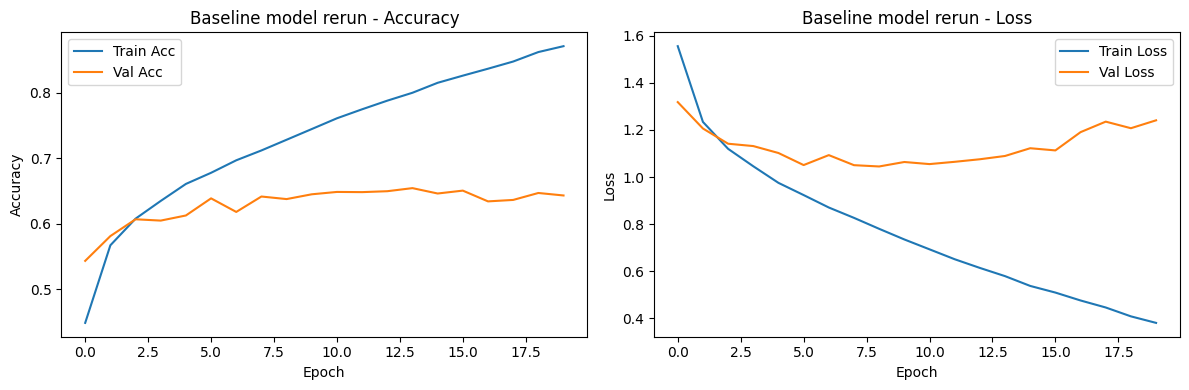

Logged results for 'Baseline model rerun':
  Train Acc: 0.8707 | Val Acc: 0.6431 | Time: 0.78 min


In [ ]:
train_and_log(
    model=model,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Baseline model rerun',
    notes='baseline simple model-1 conv layer',
    epochs=20,
    batch_size=96,
    callbacks=None
)

## Model 2

- Deeper model
- addind more layers
- padding adeded - because if not added image is too saml or vanished - cannot learn more. Since the image size is already small.


In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_2
model_2 = [
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
    ]

model_2 = build_model(model_2)
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       819,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061,142 (4.05 MB)

 Trainable params: 1,061,142 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 172ms/step - accuracy: 0.3700 - loss: 1.7279 - val_accuracy: 0.4476 - val_loss: 1.5339
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.5278 - loss: 1.3230 - val_accuracy: 0.5733 - val_loss: 1.1895
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.6184 - loss: 1.0861 - val_accuracy: 0.6439 - val_loss: 1.0213
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.6680 - loss: 0.9523 - val_accuracy: 0.6470 - val_loss: 1.0002
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.7090 - loss: 0.8377 - val_accuracy: 0.6790 - val_loss: 0.9465
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.7371 - loss: 0.7595 - val_accuracy: 0.7055 - val_loss: 0.8792
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.7660 - loss: 0.6779 - val_accuracy: 0.7027 - val_loss: 0.8610
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.7850 - loss: 0.6159 - val_accuracy: 0.7154 -

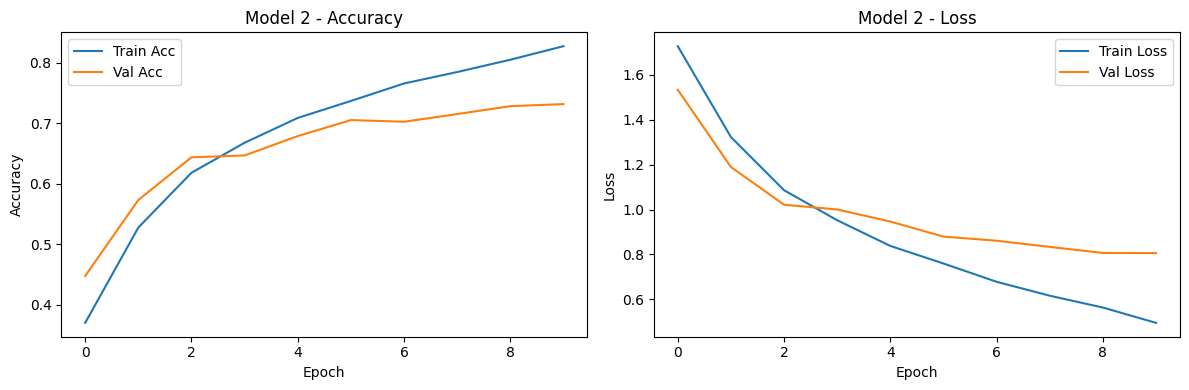

Logged results for 'Model 2':
  Train Acc: 0.8277 | Val Acc: 0.7319 | Time: 1.31 min


In [ ]:
train_and_log(
    model=model_2,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 2',
    notes='added more layers to baseline simple model with 2 conv vlocks and padding',
    epochs=10,
    batch_size=512,
    callbacks=None
)

# Model 2.1

- more deeper model
- add 4 conv block ,more layers with more filters.
- keep padding same

In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_2_1
model_2_1 = [
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')]

model_2_1 = build_model(model_2_1)
model_2_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,871,958 (18.59 MB)

 Trainable params: 4,871,958 (18.59 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - accuracy: 0.2597 - loss: 1.9479 - val_accuracy: 0.4083 - val_loss: 1.5683
Epoch 2/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.4963 - loss: 1.3621 - val_accuracy: 0.5566 - val_loss: 1.2067
Epoch 3/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.6202 - loss: 1.0585 - val_accuracy: 0.6377 - val_loss: 0.9996
Epoch 4/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.6907 - loss: 0.8675 - val_accuracy: 0.6991 - val_loss: 0.8553
Epoch 5/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.7430 - loss: 0.7236 - val_accuracy: 0.7247 - val_loss: 0.7818
Epoch 6/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.7842 - loss: 0.6079 - val_accuracy: 0.7475 - val_loss: 0.7409
Epoch 7/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8271 - loss: 0.4913 - val_accuracy: 0.7664 - val_loss: 0.7121
Epoch 8/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8601 - loss: 0.3956 - 

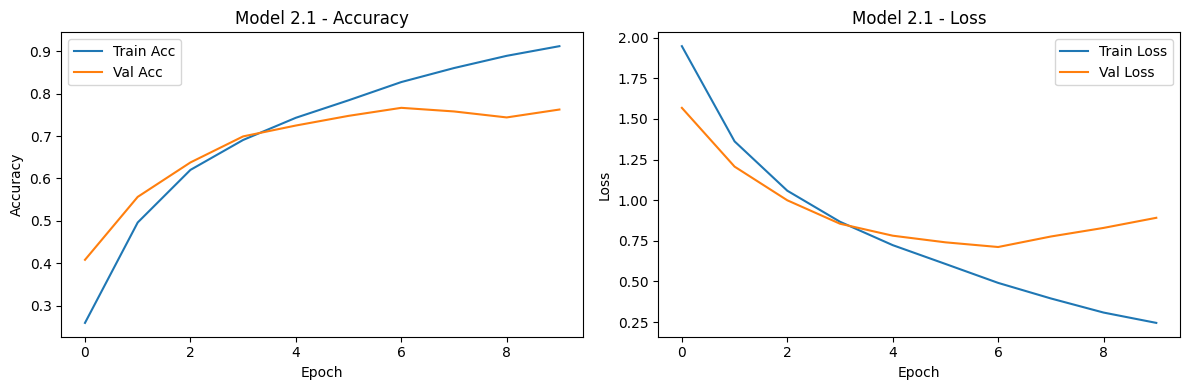

Logged results for 'Model 2.1':
  Train Acc: 0.9117 | Val Acc: 0.7624 | Time: 2.62 min


In [ ]:
train_and_log(
    model=model_2_1,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 2.1',
    notes='Deeper model with 4 conv blocks and more filters 96 batch size',
    epochs=10,
    batch_size=96,
    callbacks=None
)

# model 2.2

- add batch nornalization and dropout


In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_2_2
model_2_2 = [
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')]

model_2_2 = build_model(model_2_2)
model_2_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,01

 Total params: 4,875,798 (18.60 MB)

 Trainable params: 4,873,878 (18.59 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 270ms/step - accuracy: 0.2834 - loss: 2.0692 - val_accuracy: 0.1000 - val_loss: 4.7522
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 156ms/step - accuracy: 0.4590 - loss: 1.4622 - val_accuracy: 0.1000 - val_loss: 4.9885
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.5616 - loss: 1.2040 - val_accuracy: 0.1356 - val_loss: 5.3206
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.6446 - loss: 0.9973 - val_accuracy: 0.1736 - val_loss: 5.0258
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.7010 - loss: 0.8463 - val_accuracy: 0.1617 - val_loss: 4.2489
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.7436 - loss: 0.7324 - val_accuracy: 0.2781 - val_loss: 3.3882
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.7725 - loss: 0.6530 - val_accuracy: 0.6572 - val_loss: 1.0500
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.7978 - loss: 0.5817 - val_accu

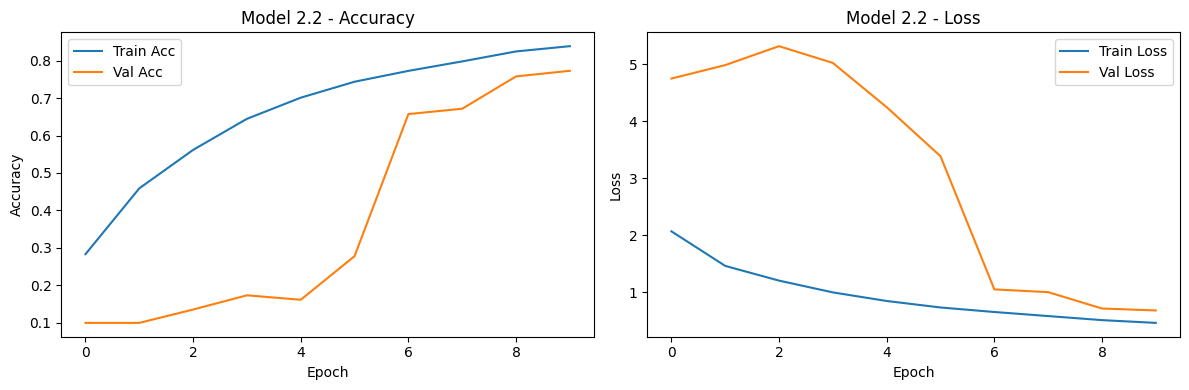

Logged results for 'Model 2.2':
  Train Acc: 0.8384 | Val Acc: 0.7727 | Time: 2.54 min


In [ ]:
train_and_log(
    model=model_2_2,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 2.2',
    notes='Add batch normalization and dropout to reduce overfitting',
    epochs=10,
    batch_size=512,
    callbacks=None
)

# model 3 resize image
-64*64
- increase filter in 1st layer
- add calbacks - early stopping , reduce lr

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-7
)


In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_3
model_3 = [
    Resizing(64, 64, input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')]

model_3 = build_model(model_3)
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       460,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,151,126 (19.65 MB)

 Trainable params: 5,149,206 (19.64 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 111s 778ms/step - accuracy: 0.3001 - loss: 2.2952 - val_accuracy: 0.1000 - val_loss: 3.8559 - learning_rate: 0.0010
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 365ms/step - accuracy: 0.4446 - loss: 1.5073 - val_accuracy: 0.1001 - val_loss: 4.1389 - learning_rate: 0.0010
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.5289 - loss: 1.2905
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 360ms/step - accuracy: 0.5458 - loss: 1.2450 - val_accuracy: 0.1017 - val_loss: 4.7431 - learning_rate: 0.0010
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - accuracy: 0.6355 - loss: 1.0104 - val_accuracy: 0.1077 - val_loss: 4.7000 - learning_rate: 2.0000e-04
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 367ms/step - accuracy: 0.6752 - loss: 0.9041 - val_accuracy: 0.1818 - val_loss: 3.8468 - learning_rate: 2.0000e-04


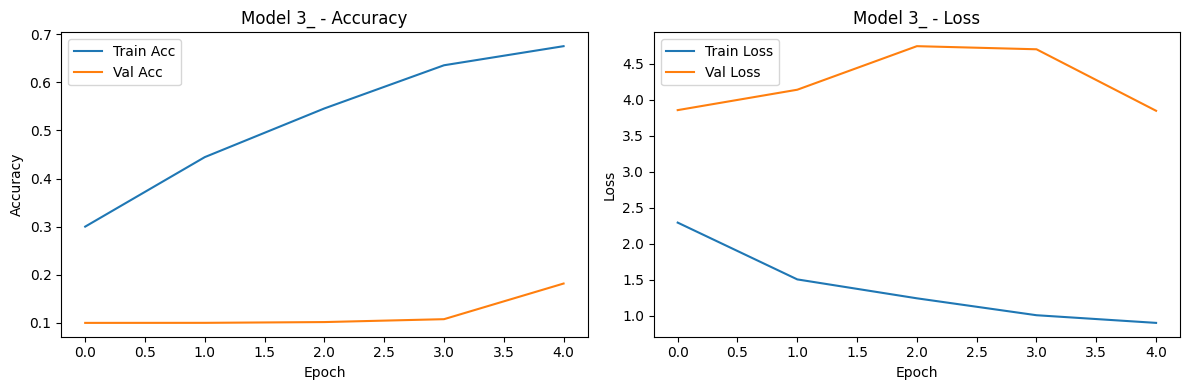

Logged results for 'Model 3_':
  Train Acc: 0.6752 | Val Acc: 0.1818 | Time: 3.79 min


In [ ]:
train_and_log(
    model=model_3,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 3',
    notes='Resize image 64*64, add callbacks',
    epochs=10,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
)

# model 4

- model 2.2 with calbacks

In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_4
model_4 = [
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')]

model_4 = build_model(model_4)
model_4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,01

 Total params: 4,875,798 (18.60 MB)

 Trainable params: 4,873,878 (18.59 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 283ms/step - accuracy: 0.2846 - loss: 2.0681 - val_accuracy: 0.1000 - val_loss: 3.0714 - learning_rate: 0.0010
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.4669 - loss: 1.4394 - val_accuracy: 0.1000 - val_loss: 3.9746 - learning_rate: 0.0010
Epoch 3/10
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5456 - loss: 1.2393
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.5683 - loss: 1.1894 - val_accuracy: 0.1007 - val_loss: 5.5811 - learning_rate: 0.0010
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.6542 - loss: 0.9617 - val_accuracy: 0.1090 - val_loss: 5.1779 - learning_rate: 2.0000e-04
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 0.6902 - loss: 0.8739 - val_accuracy: 0.1658 - val_loss: 4.5435 - learning_rate: 2.0000e-04


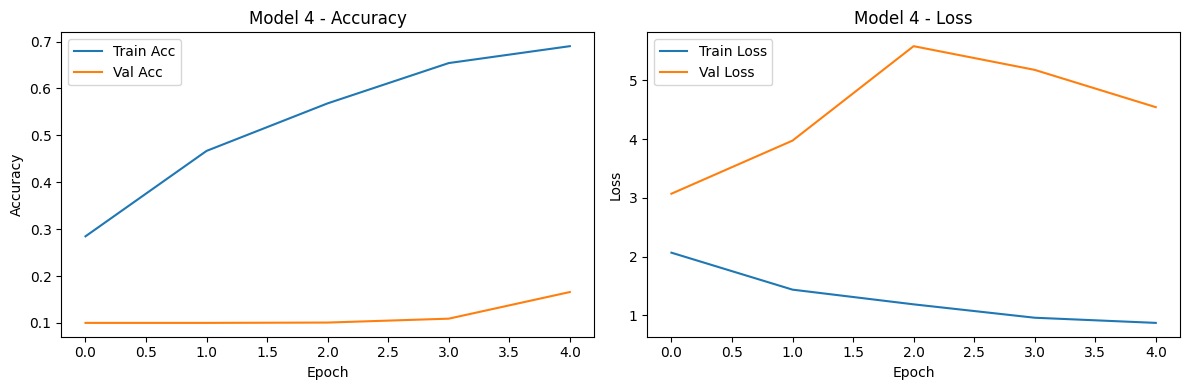

Logged results for 'Model 4':
  Train Acc: 0.6902 | Val Acc: 0.1658 | Time: 1.40 min


In [ ]:
train_and_log(
    model=model_4,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 4',
    notes='batch normalization and dropout and calbacks',
    epochs=10,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
)

# model 4.1

- with data augmentation
- keeping augmentations simple cause the priginal images are very small 32*32 and highly downsampled.

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    #layers.RandomRotation(0.1),
    #layers.RandomZoom(0.1),
    #layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.05),
    layers.RandomBrightness(0.05),
    #layers.RandomHeight(0.1),

])

In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_4_1
model_4_1 = [
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')]

model_4_1 = build_model(model_4_1)
model_4_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,90

 Total params: 4,875,798 (18.60 MB)

 Trainable params: 4,873,878 (18.59 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 308ms/step - accuracy: 0.1012 - loss: 2.5048 - val_accuracy: 0.0992 - val_loss: 2.3027 - learning_rate: 0.0010
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.0990 - loss: 2.3027 - val_accuracy: 0.0993 - val_loss: 2.3026 - learning_rate: 0.0010
Epoch 3/10
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.1002 - loss: 2.3026
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.0984 - loss: 2.3026 - val_accuracy: 0.0923 - val_loss: 2.3040 - learning_rate: 0.0010
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.1001 - loss: 2.3026 - val_accuracy: 0.1011 - val_loss: 2.3028 - learning_rate: 2.0000e-04
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.0994 - loss: 2.3025 - val_accuracy: 0.0973 - val_loss: 2.3032 - learning_rate: 2.0000e-04


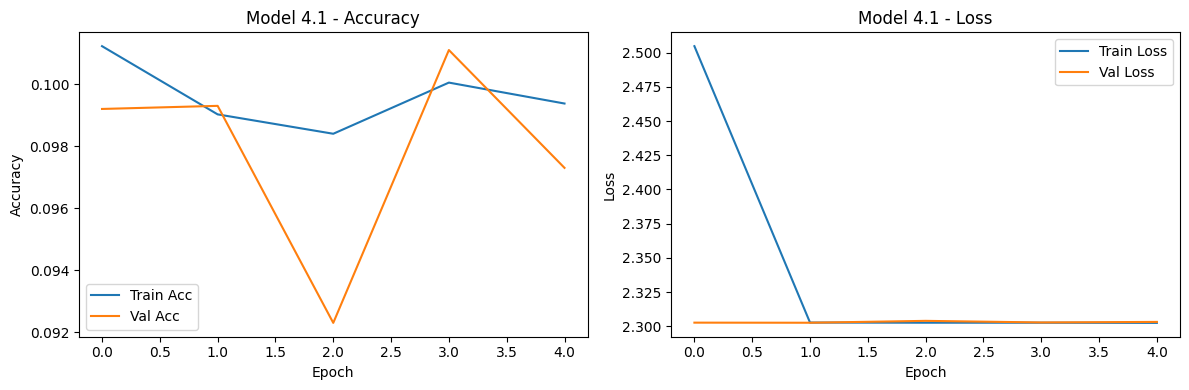

Logged results for 'Model 4.1':
  Train Acc: 0.0994 | Val Acc: 0.0973 | Time: 1.46 min


In [ ]:
train_and_log(
    model=model_4_1,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 4.1',
    notes='Data augmentation',
    epochs=10,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
)

# model 4.2
- model 2.2 with calbacks, batch size 96 - for generalization

In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_4_2
model_4_2 = [
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')]

model_4_2 = build_model(model_4_2)
model_4_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,01

 Total params: 4,875,798 (18.60 MB)

 Trainable params: 4,873,878 (18.59 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.4113 - loss: 1.6360 - val_accuracy: 0.2233 - val_loss: 2.3815 - learning_rate: 0.0010
Epoch 2/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.6045 - loss: 1.1089 - val_accuracy: 0.6755 - val_loss: 0.9283 - learning_rate: 0.0010
Epoch 3/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6905 - loss: 0.8778
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
417/417 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.7004 - loss: 0.8516 - val_accuracy: 0.6312 - val_loss: 1.2001 - learning_rate: 0.0010
Epoch 4/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.7853 - loss: 0.6133 - val_accuracy: 0.7775 - val_loss: 0.6351 - learning_rate: 2.0000e-04
Epoch 5/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8120 - loss: 0.5366 - val_accuracy: 0.7959 - val_loss: 0.5908 - learning_rate: 2.0000e-04


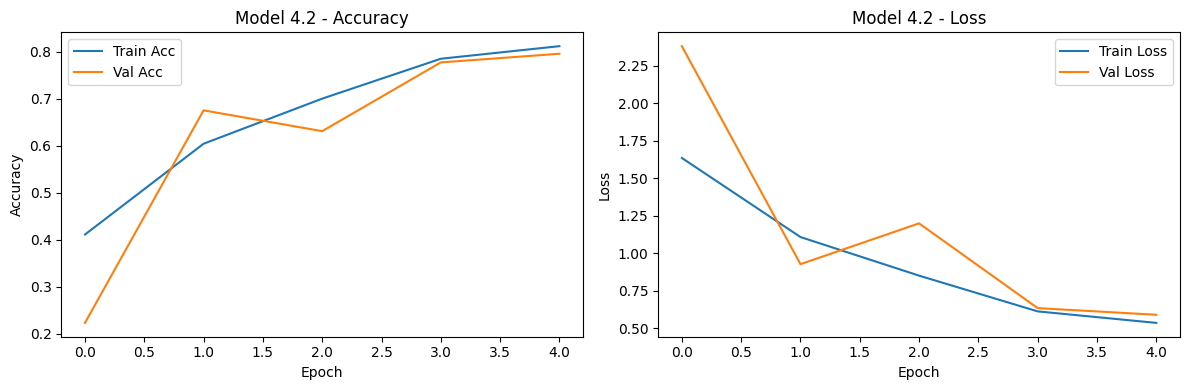

Logged results for 'Model 4.2':
  Train Acc: 0.8120 | Val Acc: 0.7959 | Time: 1.78 min


In [ ]:
train_and_log(
    model=model_4_2,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    model_name='Model 4.2',
    notes='reduce batch size with calbacks',
    epochs=10,
    batch_size=96,
    callbacks=[early_stop, reduce_lr],
)

# model 5
- model 4.2 upgraded
- increase filter in 1st layer, dense layer, epochs

In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_5
model_5 = [
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')]

model_5 = build_model(model_5)
model_5.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,29

 Total params: 4,952,778 (18.89 MB)

 Trainable params: 4,950,858 (18.89 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.3802 - loss: 1.7539 - val_accuracy: 0.2519 - val_loss: 2.6058 - learning_rate: 0.0010
Epoch 2/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.5802 - loss: 1.1725 - val_accuracy: 0.6322 - val_loss: 1.0488 - learning_rate: 0.0010
Epoch 3/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6629 - loss: 0.9535
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
417/417 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.6791 - loss: 0.9133 - val_accuracy: 0.6545 - val_loss: 0.9815 - learning_rate: 0.0010
Epoch 4/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.7641 - loss: 0.6632 - val_accuracy: 0.7759 - val_loss: 0.6456 - learning_rate: 2.0000e-04
Epoch 5/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.7942 - loss: 0.5852 - val_accuracy: 0.7799 - val_loss: 0.6198 - learning_rate: 2.0000e-04


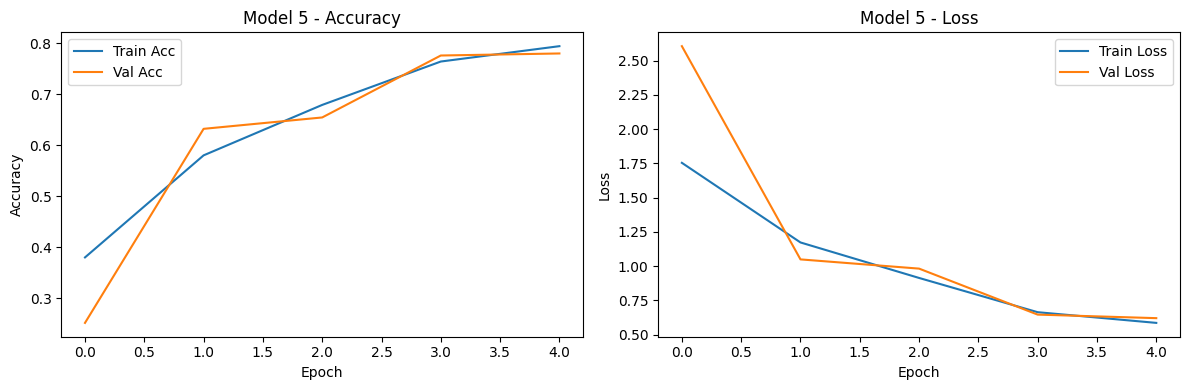

Logged results for 'Model 5':
  Train Acc: 0.7942 | Val Acc: 0.7799 | Time: 1.79 min


In [ ]:
train_and_log(
    model=model_5,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 5',
    notes='Improved model 4.2',
    epochs=20,
    batch_size=96,
    callbacks=[early_stop, reduce_lr],
)

# model 5.1
- incresae dropout

In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_5_1
model_5_1 = [
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')]

model_5_1 = build_model(model_5_1)
model_5_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,29

 Total params: 4,952,778 (18.89 MB)

 Trainable params: 4,950,858 (18.89 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 37s 62ms/step - accuracy: 0.3514 - loss: 1.7855 - val_accuracy: 0.1432 - val_loss: 3.9308 - learning_rate: 0.0010
Epoch 2/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.5227 - loss: 1.3135 - val_accuracy: 0.5697 - val_loss: 1.2670 - learning_rate: 0.0010
Epoch 3/20
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5948 - loss: 1.1224
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
417/417 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.6115 - loss: 1.0807 - val_accuracy: 0.6433 - val_loss: 1.0021 - learning_rate: 0.0010
Epoch 4/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.6903 - loss: 0.8638 - val_accuracy: 0.7213 - val_loss: 0.7859 - learning_rate: 2.0000e-04
Epoch 5/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.7185 - loss: 0.7947 - val_accuracy: 0.7311 - val_loss: 0.7601 - learning_rate: 2.0000e-04


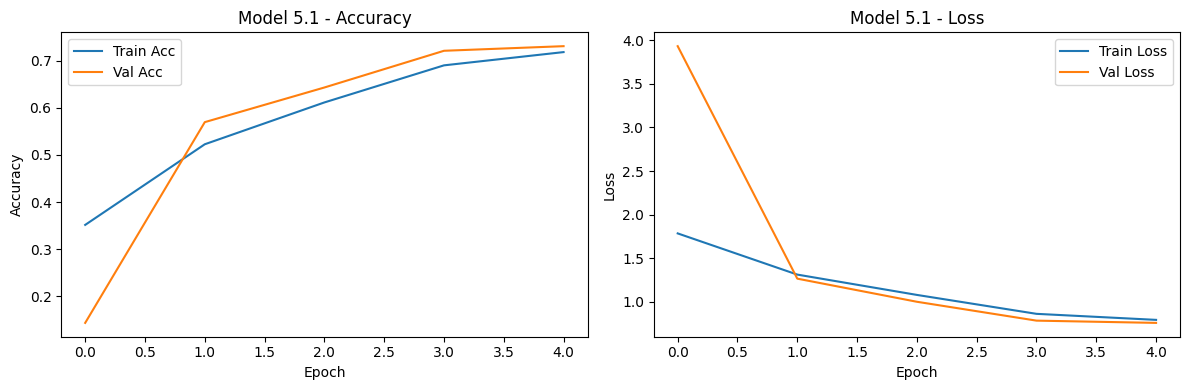

Logged results for 'Model 5.1':
  Train Acc: 0.7185 | Val Acc: 0.7311 | Time: 1.70 min


In [ ]:
train_and_log(
    model=model_5_1,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 5.1',
    notes='inceased dropout model 5',
    epochs=20,
    batch_size=96,
    callbacks=[early_stop, reduce_lr],
)

# model 6
- model 4.2 upgraded model

In [ ]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_6
model_6 = [
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')]

model_6 = build_model(model_6)
model_6.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,29

 Total params: 4,933,450 (18.82 MB)

 Trainable params: 4,931,530 (18.81 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.4012 - loss: 1.6564 - val_accuracy: 0.2590 - val_loss: 2.6722 - learning_rate: 0.0010
Epoch 2/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.6072 - loss: 1.0982 - val_accuracy: 0.5539 - val_loss: 1.2772 - learning_rate: 0.0010
Epoch 3/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6887 - loss: 0.8864
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
417/417 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.7011 - loss: 0.8521 - val_accuracy: 0.7093 - val_loss: 0.8241 - learning_rate: 0.0010
Epoch 4/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.7833 - loss: 0.6168 - val_accuracy: 0.7862 - val_loss: 0.6184 - learning_rate: 2.0000e-04
Epoch 5/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.8073 - loss: 0.5463 - val_accuracy: 0.7934 - val_loss: 0.6041 - learning_rate: 2.0000e-04


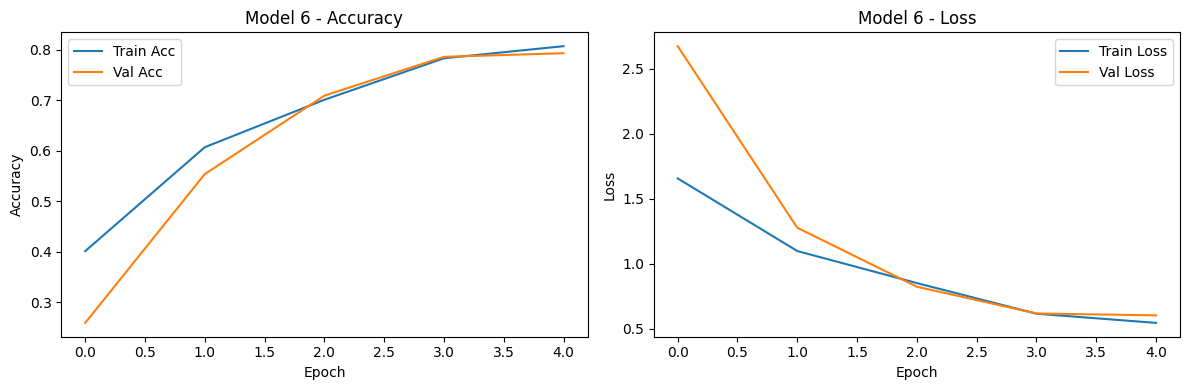

Logged results for 'Model 6':
  Train Acc: 0.8073 | Val Acc: 0.7934 | Time: 1.64 min


In [ ]:
train_and_log(
    model=model_6,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 6',
    notes='Improved model 4.2',
    epochs=20,
    batch_size=96,
    callbacks=[early_stop, reduce_lr],
)

# compare results

In [ ]:
results_df = pd.read_csv('cnn_model_experiment_results.csv')
results_df

,model_name,notes,epochs,batch_size,train_acc,train_loss,val_acc,val_loss,total_params,train_time_min,timestamp,diff_train_val_acc,diff_train_val_loss
0,Baseline model,baseline simple model-1 conv layer,10,512,0.649175,1.015623,0.6030,1.153023,722006,0.85,2026-07-03 02:14:19,0.046175,-0.137399
1,Model 2,added more layers to baseline simple model wit...,10,512,0.946500,0.152591,0.7338,1.247846,1061142,1.59,2026-07-03 02:24:44,0.212700,-1.095256
2,Model 2.1,Deeper model with 4 conv blocks and more filters,10,512,0.098925,2.302757,0.1000,2.302663,4871958,3.82,2026-07-03 02:32:46,-0.001075,0.000094
3,Baseline model,baseline simple model-1 conv layer,10,512,0.781700,0.622618,0.6371,1.146666,722006,0.99,2026-07-03 07:05:27,0.144600,-0.524048
4,Baseline model,baseline simple model-1 conv layer,10,512,0.710600,0.844767,0.6397,1.062371,722006,0.19,2026-07-03 07:10:44,0.070900,-0.217604
5,Model 2,added more layers to baseline simple model wit...,10,512,0.827725,0.494875,0.7319,0.805932,1061142,1.31,2026-07-03 07:14:33,0.095825,-0.311056
6,Model 2.1,Deeper model with 4 conv blocks and more filters,10,512,0.853825,0.410960,0.7583,0.733354,4871958,2.50,2026-07-03 07:17:57,0.095525,-0.322394
7,Model 2.1,Deeper model with 4 conv blocks and more filte...,10,96,0.911700,0.245239,0.7624,0.891818,4871958,2.62,2026-07-03 07:31:02,0.149300,-0.646578
8,Model 2.2,Add batch normalization and dropout to reduce ...,10,512,0.908400,0.262685,0.7757,0.740854,4875798,2.37,2026-07-03 07:50:10,0.132700,-0.478169
9,Model 2.2,Add batch normalization and dropout to reduce ...,10,512,0.838425,0.461911,0.7727,0.680269,4875798,2.54,2026-07-03 07:56:08,0.065725,-0.218358


In [ ]:
results_df['diff_train_val_acc'] = results_df['train_acc'] - results_df['val_acc']
results_df['diff_train_val_loss'] = results_df['train_loss'] - results_df['val_loss']
#results_df

In [ ]:
results_df.sort_values('val_acc', ascending=False)

,model_name,notes,epochs,batch_size,train_acc,train_loss,val_acc,val_loss,total_params,train_time_min,timestamp,diff_train_val_acc,diff_train_val_loss
11,Model 3,"Resize image 64*64, add callbacks",5,96,0.972775,0.080493,0.8502,0.547803,4875798,1.43,2026-07-03 08:23:17,0.122575,-0.467310
10,Model 3,"Resize image 64*64, add callbacks",10,512,0.975950,0.074820,0.8473,0.547903,4875798,2.07,2026-07-03 08:18:31,0.128650,-0.473084
16,Model 4.2,reduce batch size with calbacks,5,96,0.812050,0.536644,0.7959,0.590833,4875798,1.78,2026-07-03 09:19:29,0.016150,-0.054190
20,Model 6,Improved model 4.2,5,96,0.807350,0.546308,0.7934,0.604146,4933450,1.64,2026-07-03 09:47:21,0.013950,-0.057838
17,Model 5,Improved model 4.2,5,96,0.794200,0.585186,0.7799,0.619756,4952778,1.79,2026-07-03 09:26:02,0.014300,-0.034570
8,Model 2.2,Add batch normalization and dropout to reduce ...,10,512,0.908400,0.262685,0.7757,0.740854,4875798,2.37,2026-07-03 07:50:10,0.132700,-0.478169
9,Model 2.2,Add batch normalization and dropout to reduce ...,10,512,0.838425,0.461911,0.7727,0.680269,4875798,2.54,2026-07-03 07:56:08,0.065725,-0.218358
7,Model 2.1,Deeper model with 4 conv blocks and more filte...,10,96,0.911700,0.245239,0.7624,0.891818,4871958,2.62,2026-07-03 07:31:02,0.149300,-0.646578
6,Model 2.1,Deeper model with 4 conv blocks and more filters,10,512,0.853825,0.410960,0.7583,0.733354,4871958,2.50,2026-07-03 07:17:57,0.095525,-0.322394
1,Model 2,added more layers to baseline simple model wit...,10,512,0.946500,0.152591,0.7338,1.247846,1061142,1.59,2026-07-03 02:24:44,0.212700,-1.095256


## Comments

### Choosing model 4.2 for following reasons:
- Val accuracy of 79%
- difference in train and val acc is very low. same with train and val loss. Indicates good generalization.
- Train time is fast ~2m

- Modle 3 is overfitting hence not selected even if higher accuracy


